# 03 — Regression Analysis: OD vs SD (M Repetitions)

Fit a standard multiple linear regression model on each pair of **Original Data (OD)** and **Synthetic Data (SD)** datasets across **M** repetitions per correlation setting.  
Compare estimated coefficients and produce rich visualisations that aggregate results over all repetitions.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import json
import os
import re
import glob
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.family": "sans-serif",
})

In [2]:
# ── Load Configuration ──────────────────────────────────────────────────────
config_path = os.path.join("..", "config", "config.json")
with open(config_path, "r") as f:
    config = json.load(f)

M        = config["simulation"]["M"]
rho_vals = config["parameters"]["rho"]
beta_true = np.array(config["parameters"]["beta"])
p         = config["simulation"]["p"]

print("Configuration loaded:")
print(json.dumps(config, indent=2))
print(f"\nM = {M} repetitions, rho values = {rho_vals}")

Configuration loaded:
{
  "simulation": {
    "N": 10000,
    "p": 10,
    "sigma_2": 1,
    "random_seed_base": 16,
    "test_seed": 123,
    "N_test": 10000,
    "M": 50
  },
  "parameters": {
    "rho": [
      0.0,
      0.3,
      0.5
    ],
    "beta": [
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1
    ]
  },
  "synthesis": {
    "method": "cart"
  }
}

M = 50 repetitions, rho values = [0.0, 0.3, 0.5]


In [3]:
# ── Discover matched OD / SD file pairs ────────────────────────────────────
od_dir = os.path.join("..", "data", "original")
sd_dir = os.path.join("..", "data", "synthetic")
model_dir = os.path.join("..", "models")
result_dir = os.path.join("..", "results")
os.makedirs(model_dir, exist_ok=True)
os.makedirs(result_dir, exist_ok=True)

od_files = sorted(glob.glob(os.path.join(od_dir, "OD_*.csv")))
sd_files = sorted(glob.glob(os.path.join(sd_dir, "SD_*.csv")))

assert len(od_files) > 0, f"No OD files found in {od_dir}"
assert len(od_files) == len(sd_files), (
    f"Mismatch: {len(od_files)} OD vs {len(sd_files)} SD files"
)

print(f"Found {len(od_files)} OD/SD pair(s)  ({len(rho_vals)} rho values × {M} reps)")
print(f"First: {os.path.basename(od_files[0])}")
print(f"Last:  {os.path.basename(od_files[-1])}")

Found 150 OD/SD pair(s)  (3 rho values × 50 reps)
First: OD_N10000_p10_rho0.0_rep1.csv
Last:  OD_N10000_p10_rho0.5_rep9.csv


## Fit OLS Models

For each scenario (rho × repetition), fit $y = X\beta + \epsilon$ on both the OD and SD datasets using ordinary least squares.  
Aggregate coefficient estimates and $R^2$ across all M repetitions.

In [4]:
# ── Helper: parse rho and rep from filename ─────────────────────────────────
def parse_scenario(filename):
    """Extract rho and rep from filename like OD_N10000_p10_rho0.3_rep5.csv"""
    m = re.search(r"rho([\d.]+)_rep(\d+)", filename)
    if m:
        return float(m.group(1)), int(m.group(2))
    # Fallback for old naming (no rep)
    m = re.search(r"rho([\d.]+)", filename)
    if m:
        return float(m.group(1)), 1
    raise ValueError(f"Cannot parse rho/rep from {filename}")


# ── Fit models for every OD / SD pair ──────────────────────────────────────
results = []       # per-(rho, rep) summary rows
coef_rows = []     # per-coefficient rows for long-format analysis

terms = ["β₀ (intercept)"] + [f"β{i+1}" for i in range(p)]

for od_path, sd_path in zip(od_files, sd_files):
    od = pd.read_csv(od_path)
    sd = pd.read_csv(sd_path)

    rho, rep = parse_scenario(os.path.basename(od_path))

    X_od, y_od = od.drop(columns="y"), od["y"]
    X_sd, y_sd = sd.drop(columns="y"), sd["y"]

    lm_od = LinearRegression().fit(X_od, y_od)
    lm_sd = LinearRegression().fit(X_sd, y_sd)

    r2_od = r2_score(y_od, lm_od.predict(X_od))
    r2_sd = r2_score(y_sd, lm_sd.predict(X_sd))

    beta_od = np.concatenate([[lm_od.intercept_], lm_od.coef_])
    beta_sd = np.concatenate([[lm_sd.intercept_], lm_sd.coef_])

    # Save model pair
    scenario_tag = f"N{config['simulation']['N']}_p{p}_rho{rho}_rep{rep}"
    model_path = os.path.join(model_dir, f"models_{scenario_tag}.pkl")
    with open(model_path, "wb") as f:
        pickle.dump({
            "lm_od": lm_od, "lm_sd": lm_sd,
            "scenario": scenario_tag, "rho": rho, "rep": rep,
        }, f)

    results.append({
        "rho": rho, "rep": rep,
        "r2_od": r2_od, "r2_sd": r2_sd,
        "r2_diff": r2_od - r2_sd,
    })

    for j, name in enumerate(terms):
        coef_rows.append({
            "rho": rho, "rep": rep, "term": name,
            "beta_true": beta_true[j],
            "beta_od": beta_od[j], "beta_sd": beta_sd[j],
            "diff": beta_od[j] - beta_sd[j],
        })

results_df = pd.DataFrame(results)
coef_df    = pd.DataFrame(coef_rows)

print(f"Fitted {len(od_files)} model pairs.")
print(f"Results shape: {results_df.shape}, Coefficients shape: {coef_df.shape}")

Fitted 150 model pairs.
Results shape: (150, 5), Coefficients shape: (1650, 7)


## Summary Table (aggregated over M repetitions)

In [5]:
# ── Aggregate summary by rho ────────────────────────────────────────────────
summary = (
    results_df
    .groupby("rho")
    .agg(
        M=("rep", "count"),
        r2_od_mean=("r2_od", "mean"),
        r2_od_std=("r2_od", "std"),
        r2_sd_mean=("r2_sd", "mean"),
        r2_sd_std=("r2_sd", "std"),
        r2_diff_mean=("r2_diff", "mean"),
        r2_diff_std=("r2_diff", "std"),
    )
    .reset_index()
)
display(summary)

# Save full per-rep results
results_df.to_csv(os.path.join(result_dir, "regression_results_all_reps.csv"), index=False)
coef_df.to_csv(os.path.join(result_dir, "coefficient_estimates_all_reps.csv"), index=False)
print("Saved: regression_results_all_reps.csv, coefficient_estimates_all_reps.csv")

,rho,M,r2_od_mean,r2_od_std,r2_sd_mean,r2_sd_std,r2_diff_mean,r2_diff_std
0,0.0,50,0.908896,0.001655,0.465112,0.009449,0.443784,0.008922
1,0.3,50,0.973852,0.000550,0.813103,0.003976,0.160749,0.003877
2,0.5,50,0.982145,0.000359,0.890825,0.002327,0.091320,0.002189


Saved: regression_results_all_reps.csv, coefficient_estimates_all_reps.csv


## Visualisations

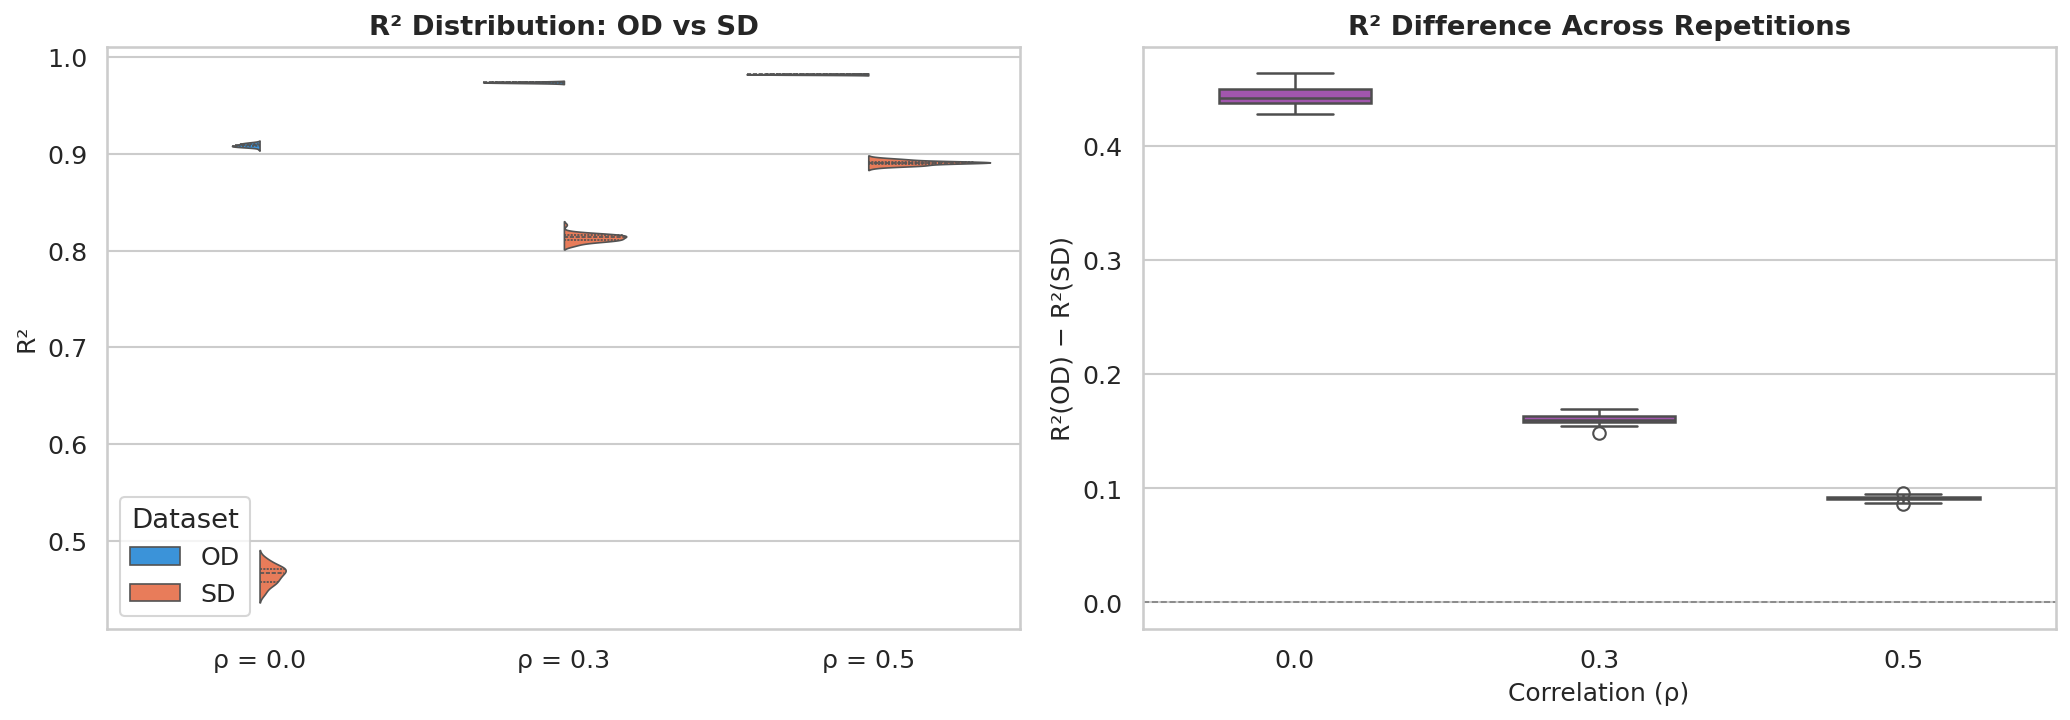

In [6]:
# ── Plot 1: R² Distribution by rho (OD vs SD) ──────────────────────────────
palette = {"OD": "#2196F3", "SD": "#FF7043"}

r2_long = pd.melt(
    results_df, id_vars=["rho", "rep"],
    value_vars=["r2_od", "r2_sd"],
    var_name="source", value_name="R²",
)
r2_long["source"] = r2_long["source"].map({"r2_od": "OD", "r2_sd": "SD"})
r2_long["ρ"] = r2_long["rho"].apply(lambda x: f"ρ = {x}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Violin plot
sns.violinplot(
    data=r2_long, x="ρ", y="R²", hue="source",
    split=True, inner="quart", palette=palette, ax=axes[0], linewidth=0.8,
)
axes[0].set_title("R² Distribution: OD vs SD")
axes[0].set_xlabel("")
axes[0].legend(title="Dataset", loc="lower left")

# (b) Box plot of R² difference
sns.boxplot(
    data=results_df, x="rho", y="r2_diff",
    color="#AB47BC", width=0.5, ax=axes[1], linewidth=1.2,
)
axes[1].axhline(0, color="grey", ls="--", lw=0.8)
axes[1].set_xlabel("Correlation (ρ)")
axes[1].set_ylabel("R²(OD) − R²(SD)")
axes[1].set_title("R² Difference Across Repetitions")

plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_r2_distributions.png"), dpi=200, bbox_inches="tight")
plt.show()

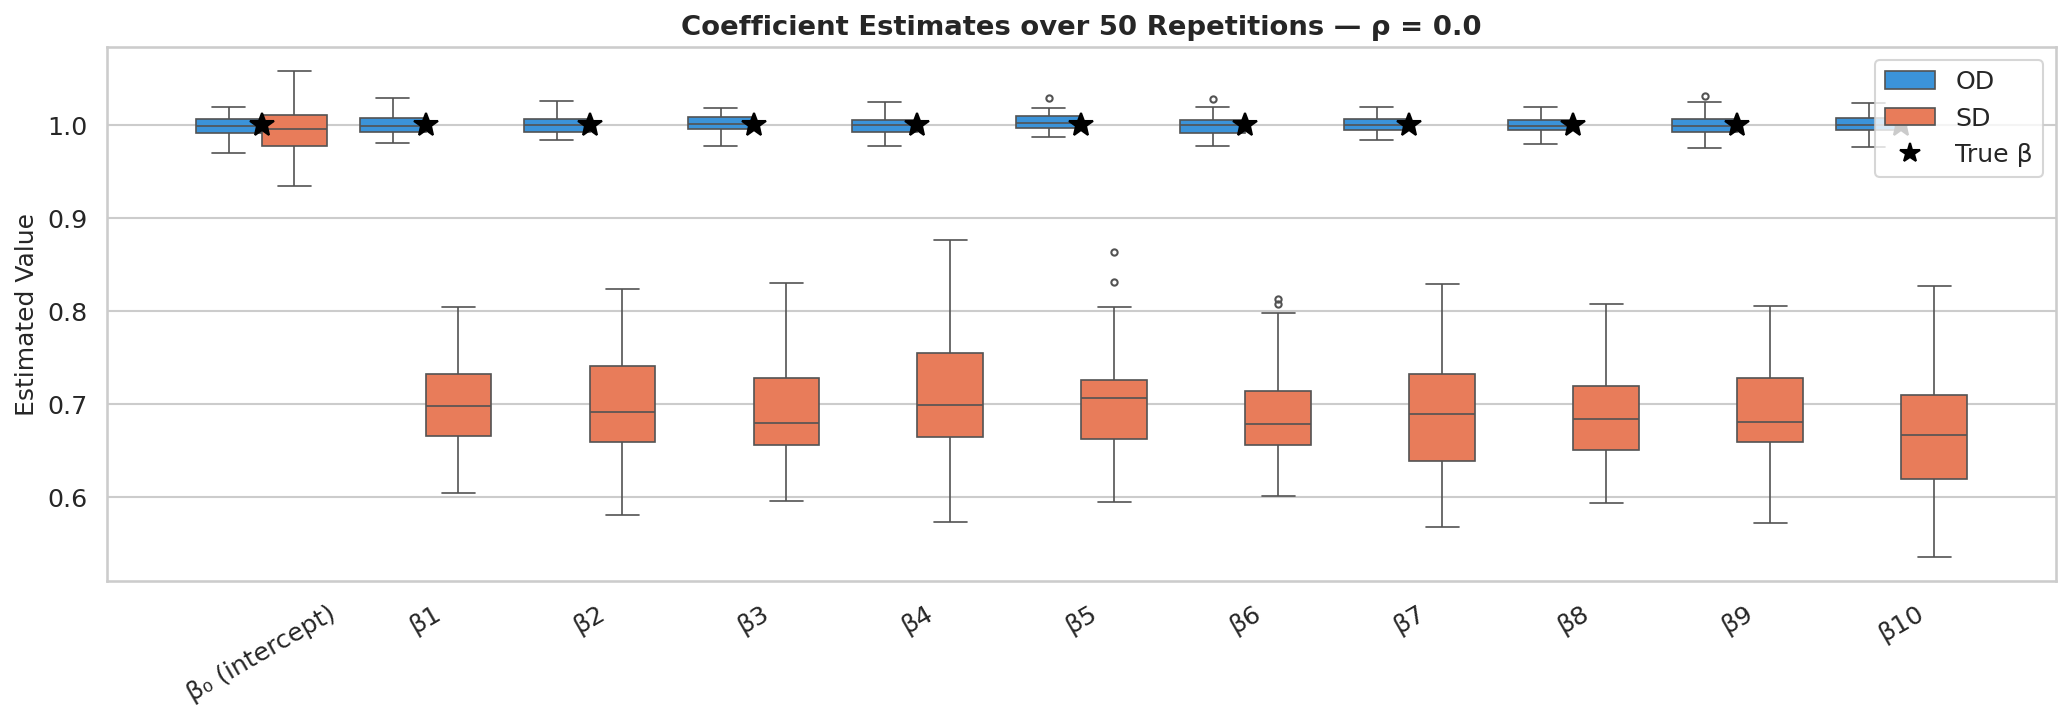

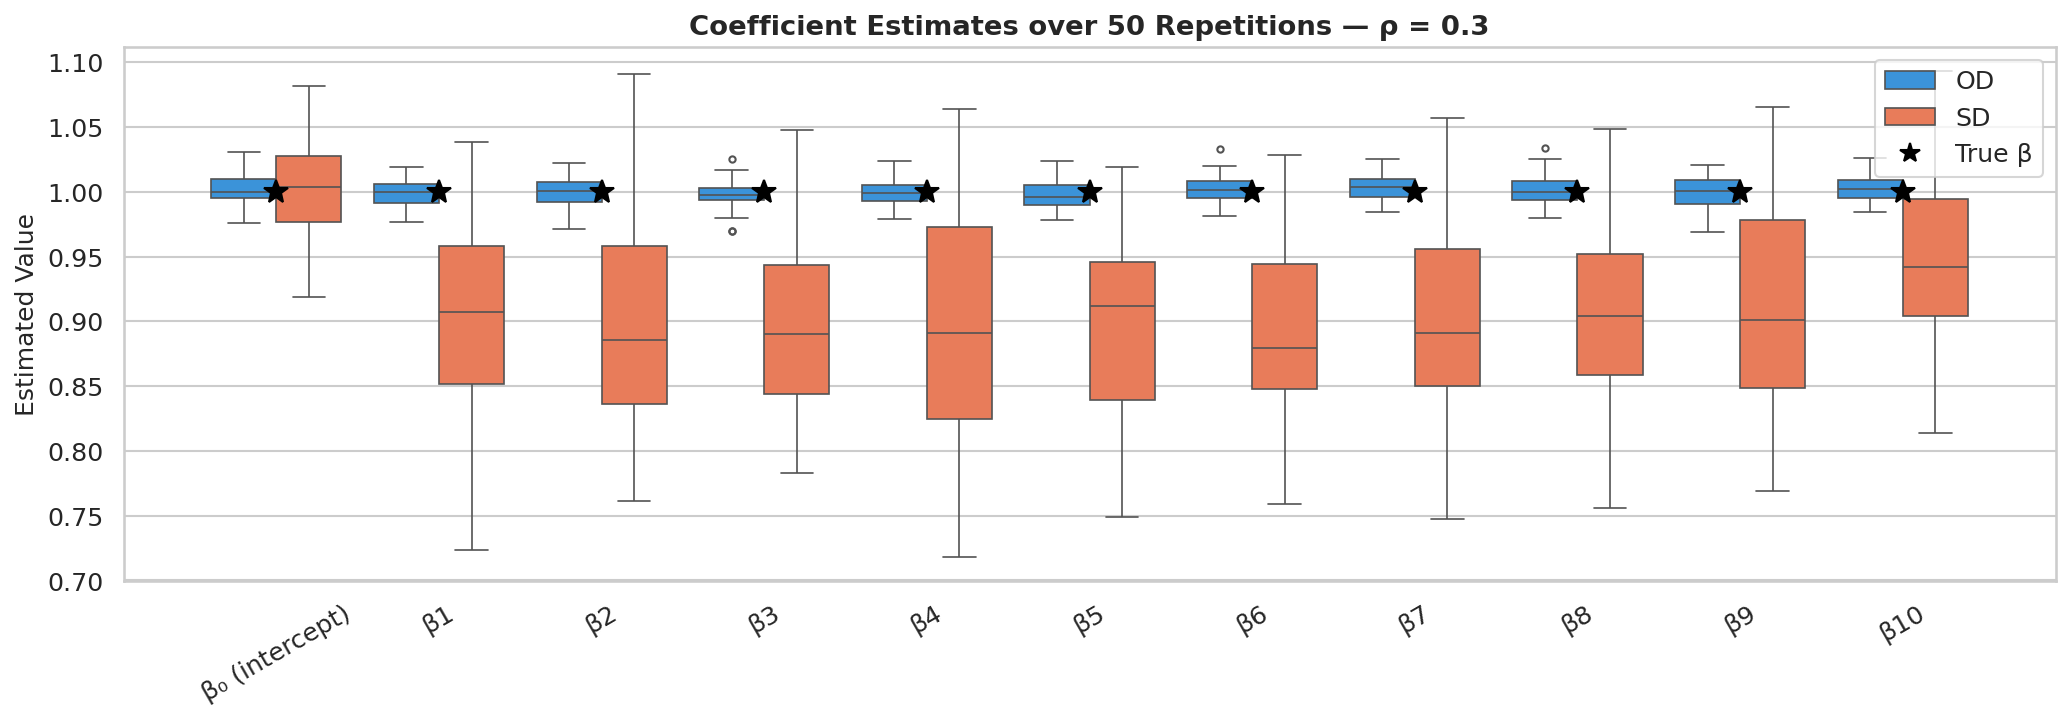

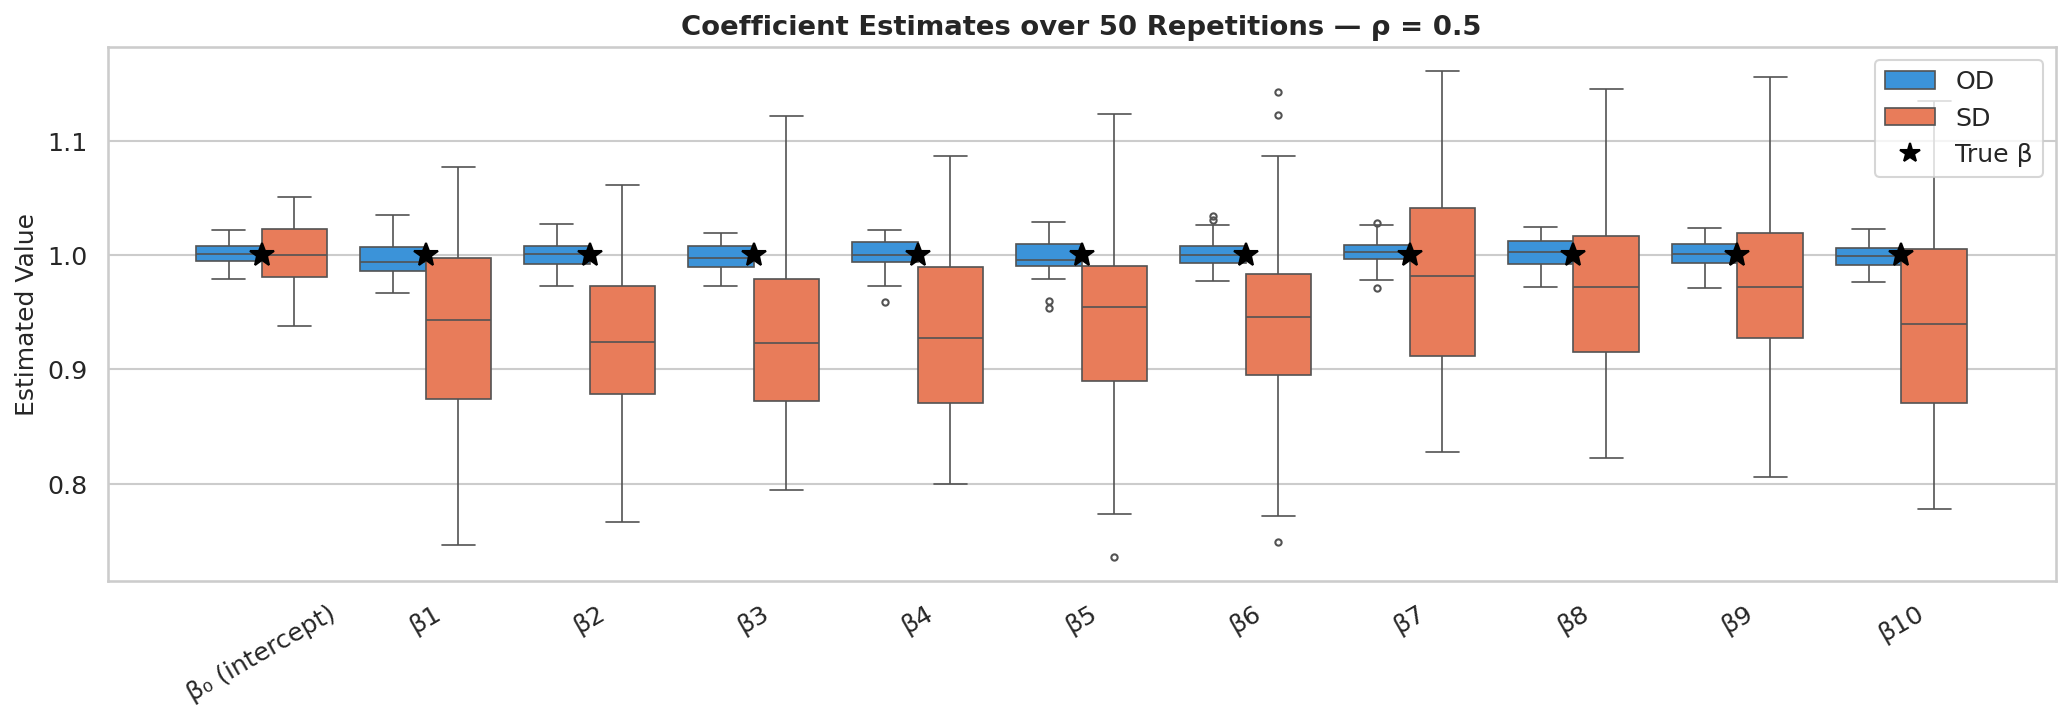

In [7]:
# ── Plot 2: Coefficient Estimates — Box Plots per rho ──────────────────────
# Show the distribution of each β estimate across M repetitions

for rho in sorted(coef_df["rho"].unique()):
    sub = coef_df[coef_df["rho"] == rho].copy()

    # Melt to long format for OD vs SD comparison
    sub_long = pd.melt(
        sub, id_vars=["rep", "term", "beta_true"],
        value_vars=["beta_od", "beta_sd"],
        var_name="source", value_name="Estimate",
    )
    sub_long["source"] = sub_long["source"].map({"beta_od": "OD", "beta_sd": "SD"})

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(
        data=sub_long, x="term", y="Estimate", hue="source",
        palette=palette, ax=ax, linewidth=0.8, fliersize=3,
    )
    # Overlay true values
    true_vals = sub.drop_duplicates("term").set_index("term")["beta_true"]
    for i, term in enumerate(sub["term"].unique()):
        ax.plot(i, true_vals[term], marker="*", color="black", markersize=12, zorder=5)

    ax.set_title(f"Coefficient Estimates over {M} Repetitions — ρ = {rho}")
    ax.set_xlabel("")
    ax.set_ylabel("Estimated Value")
    ax.tick_params(axis="x", rotation=30)
    # Custom legend
    from matplotlib.lines import Line2D
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([0], [0], marker="*", color="black", ls="", markersize=10))
    labels.append("True β")
    ax.legend(handles=handles, labels=labels, title="", loc="upper right")

    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"plot_coef_boxplot_rho{rho}.png"), dpi=200, bbox_inches="tight")
    plt.show()

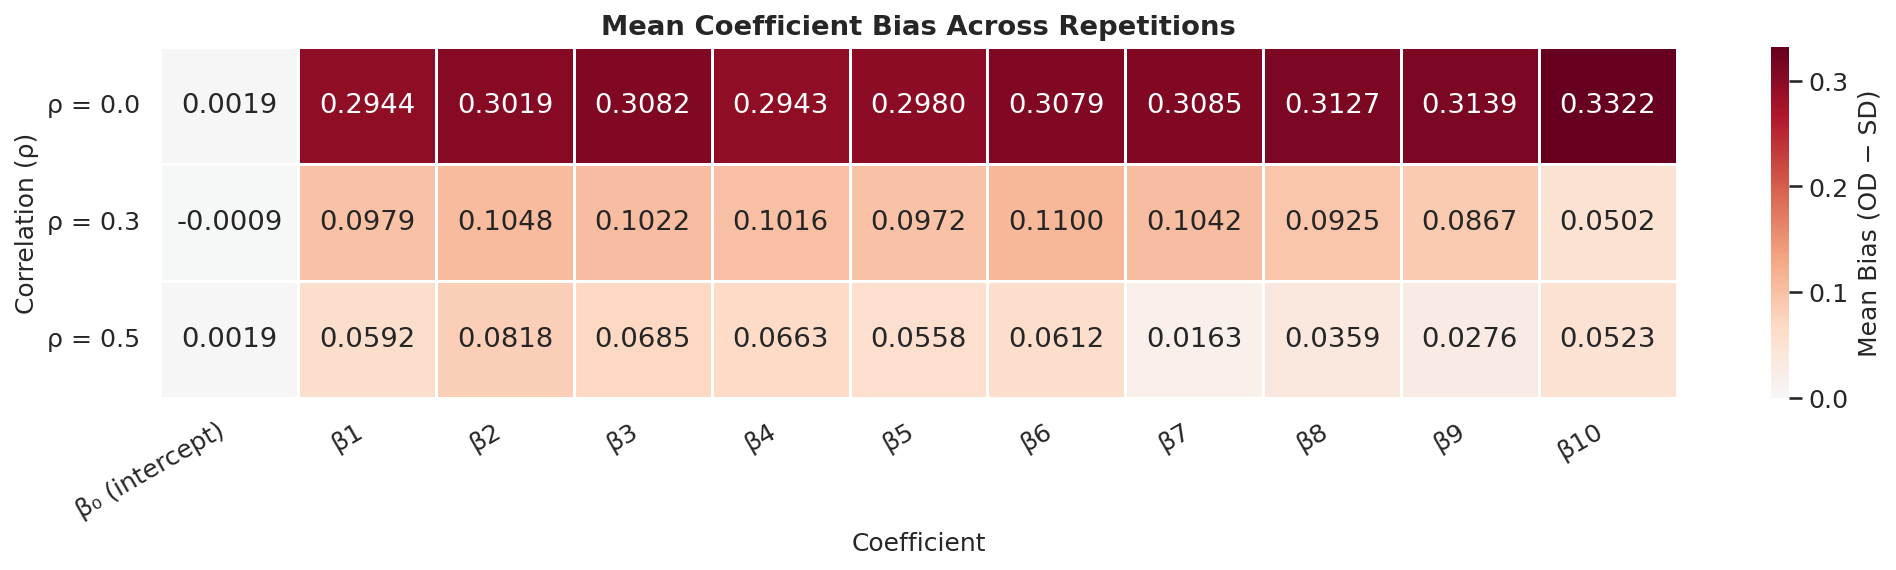

In [8]:
# ── Plot 3: Coefficient Bias Heatmap ────────────────────────────────────────
# Mean (β_OD - β_SD) for each term × rho combination

bias_pivot = (
    coef_df
    .groupby(["rho", "term"])["diff"]
    .mean()
    .unstack("term")
)
# Reorder columns
bias_pivot = bias_pivot[
    ["β₀ (intercept)"] + [f"β{i+1}" for i in range(p)]
]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    bias_pivot, annot=True, fmt=".4f", cmap="RdBu_r", center=0,
    linewidths=0.5, cbar_kws={"label": "Mean Bias (OD − SD)"},
    ax=ax,
)
ax.set_title("Mean Coefficient Bias Across Repetitions")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Correlation (ρ)")
ax.set_yticklabels([f"ρ = {v:.1f}" for v in bias_pivot.index], rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_coef_bias_heatmap.png"), dpi=200, bbox_inches="tight")
plt.show()

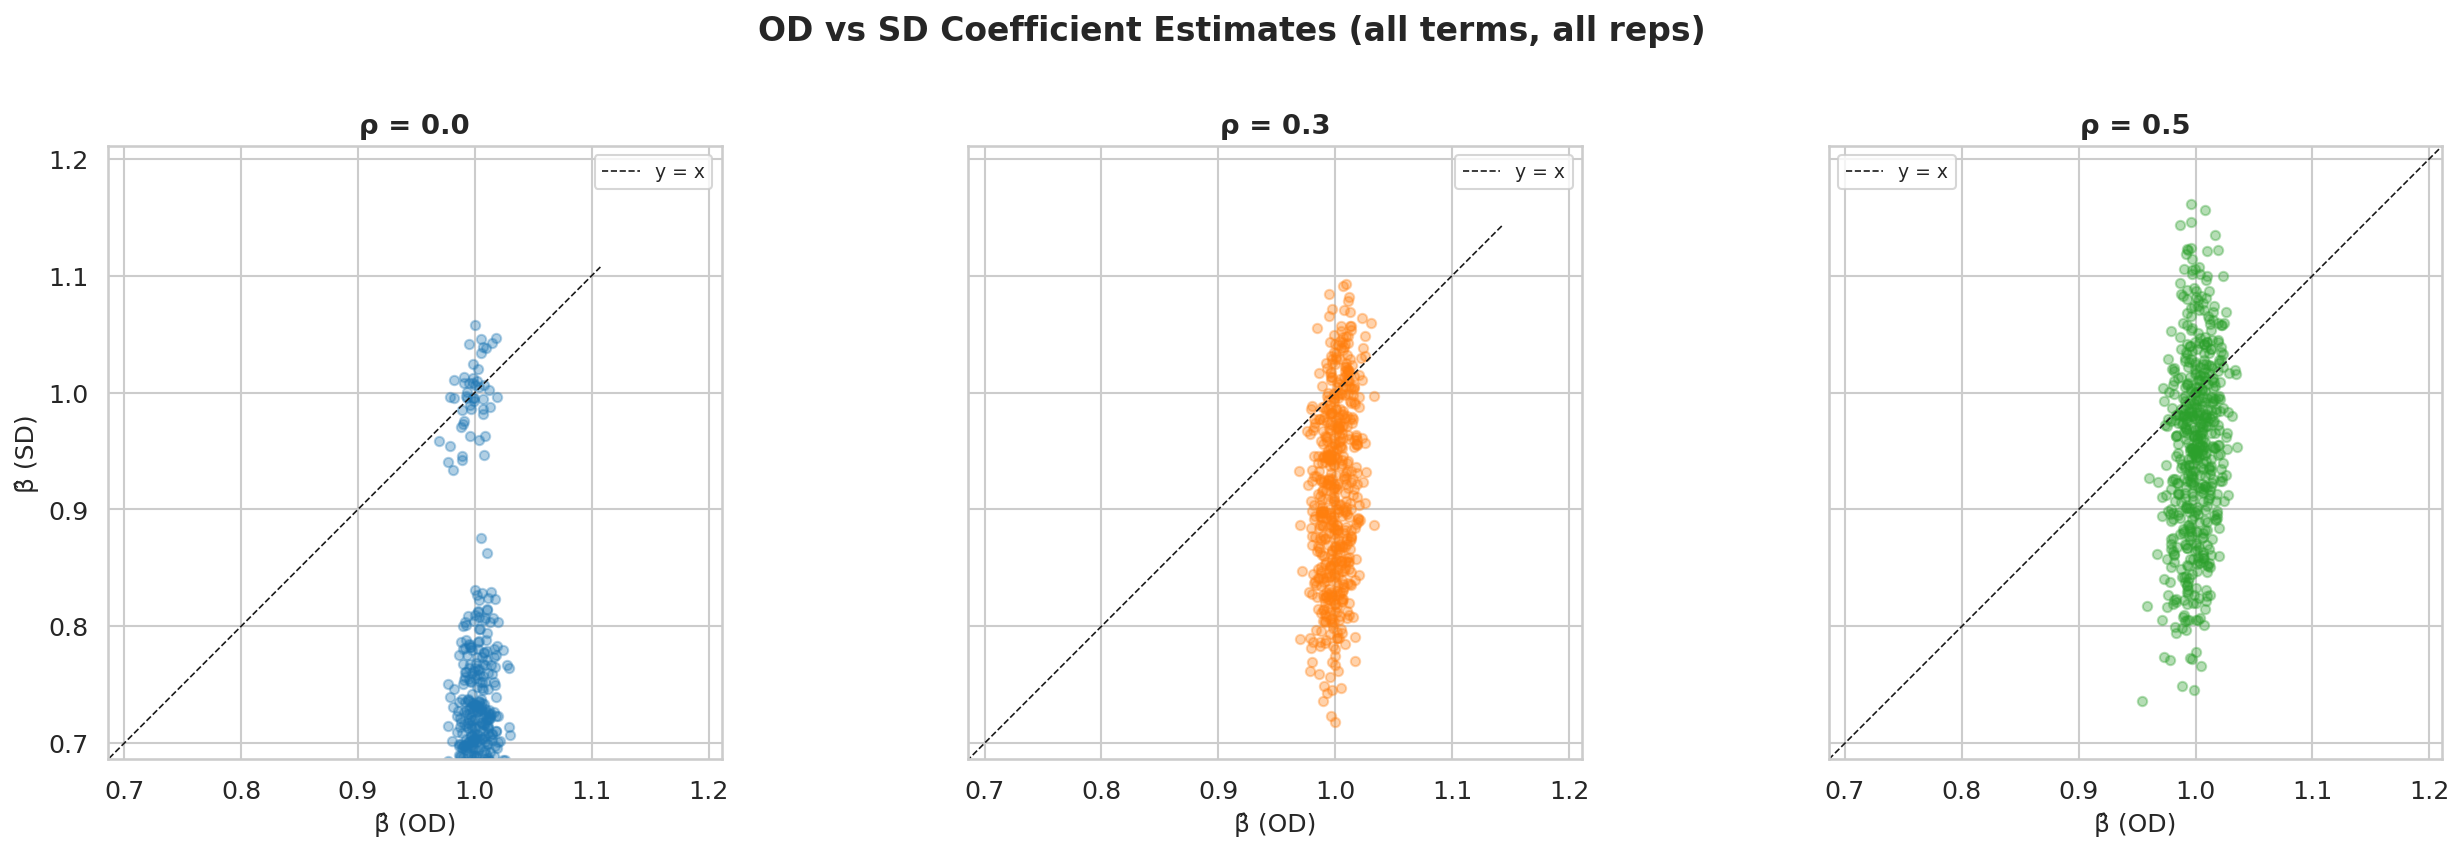

In [9]:
# ── Plot 4: Scatter — β_OD vs β_SD (per rho, all terms pooled) ─────────────
rho_unique = sorted(coef_df["rho"].unique())
n_rho = len(rho_unique)

fig, axes = plt.subplots(1, n_rho, figsize=(6 * n_rho, 5.5), sharey=True, sharex=True)
if n_rho == 1:
    axes = [axes]

cmap = plt.cm.tab10
for idx, (rho, ax) in enumerate(zip(rho_unique, axes)):
    sub = coef_df[coef_df["rho"] == rho]
    ax.scatter(sub["beta_od"], sub["beta_sd"], alpha=0.35, s=20, color=cmap(idx))

    # Identity line
    lims = [
        min(sub["beta_od"].min(), sub["beta_sd"].min()) - 0.05,
        max(sub["beta_od"].max(), sub["beta_sd"].max()) + 0.05,
    ]
    ax.plot(lims, lims, "k--", lw=0.8, label="y = x")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("β̂ (OD)")
    if idx == 0:
        ax.set_ylabel("β̂ (SD)")
    ax.set_title(f"ρ = {rho}")
    ax.set_aspect("equal")
    ax.legend(fontsize=9)

fig.suptitle("OD vs SD Coefficient Estimates (all terms, all reps)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_coef_scatter_od_vs_sd.png"), dpi=200, bbox_inches="tight")
plt.show()

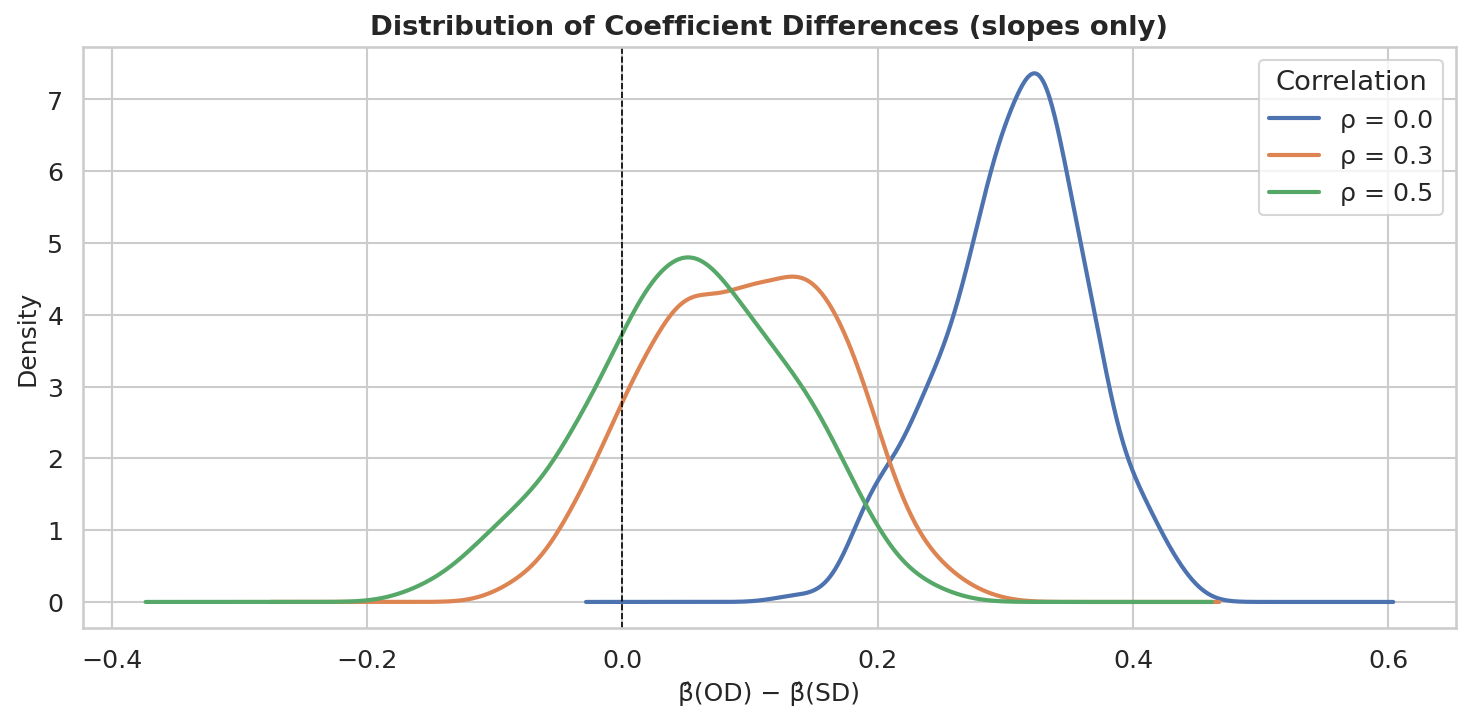


[DONE] Regression analysis complete. Models & results saved.


In [10]:
# ── Plot 5: Ridgeline-style KDE — coefficient difference distributions ─────
# Show the distribution of (β_OD - β_SD) for slope terms across rho

slope_diff = coef_df[coef_df["term"] != "β₀ (intercept)"].copy()
slope_diff["ρ"] = slope_diff["rho"].apply(lambda x: f"ρ = {x}")

fig, ax = plt.subplots(figsize=(10, 5))
for i, rho in enumerate(rho_unique):
    sub = slope_diff[slope_diff["rho"] == rho]["diff"]
    sub.plot.kde(ax=ax, label=f"ρ = {rho}", linewidth=2)

ax.axvline(0, color="black", ls="--", lw=0.8)
ax.set_xlabel("β̂(OD) − β̂(SD)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Coefficient Differences (slopes only)")
ax.legend(title="Correlation")

plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_coef_diff_kde.png"), dpi=200, bbox_inches="tight")
plt.show()

print("\n[DONE] Regression analysis complete. Models & results saved.")